## Disclaimer

Questo notebook è stato realizzato esclusivamente per scopi **didattici e illustrativi**.

L’analisi dei dati e i modelli di machine learning presentati hanno l’obiettivo di mostrare tecniche di esplorazione dei dati e modellazione predittiva applicate a un dataset sui tassi di omicidio.

I risultati ottenuti **non devono essere interpretati come previsioni affidabili** o come stime utilizzabili per analisi di policy o decisioni operative. Le dinamiche reali della criminalità dipendono da numerosi fattori sociali, economici, istituzionali e culturali che non sono inclusi in questo dataset.

Pertanto, le previsioni generate devono essere considerate **solo come un esercizio di data science**, utile a scopo dimostrativo.

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/lucalullo/global-homicide-rates-by-country/tassi-di-omicidi-globali-per-paese.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/lucalullo/global-homicide-rates-by-country/tassi-di-omicidi-globali-per-paese.csv')

In [3]:
df.head()

,iso_code,country,year,sex,age_group,homicide_rate
0,AFG,Afghanistan,2009,both,ALL,4.059550
1,AFG,Afghanistan,2010,both,ALL,3.475452
2,AFG,Afghanistan,2011,both,ALL,4.194535
3,AFG,Afghanistan,2012,both,ALL,6.374339
4,AFG,Afghanistan,2015,both,ALL,9.952186


In [4]:
from sklearn.preprocessing import LabelEncoder

# encoding categorie
le_country = LabelEncoder()
le_sex = LabelEncoder()
le_age = LabelEncoder()

df["country"] = le_country.fit_transform(df["country"])
df["sex"] = le_sex.fit_transform(df["sex"])
df["age_group"] = le_age.fit_transform(df["age_group"])

In [5]:
# Separiamo x e y
X = df[["country", "year", "sex", "age_group"]]
y = df["homicide_rate"]

In [6]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Modello
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
# Addestramento
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 2.5088906779446694
R2: 0.8297751868779955


In [9]:
# Categorie originali età
print(le_age.classes_)

['0_9' '10_14' '15_17' '18_19' '20_24' '25_29' '30_44' '45_59' '60_PLUS'
 'ALL']


In [10]:
# Categorie già trasformate in numeri dal LabelEncoder
df["age_group"].unique()

array([9, 6, 7, 8, 0, 1, 2, 3, 4, 5])

In [11]:
sample = pd.DataFrame({
    "country": [le_country.transform(["Italy"])[0]],
    "year": [2025],
    "sex": [le_sex.transform(["male"])[0]],
    "age_group": [le_age.transform(["25_29"])[0]]
})

prediction = model.predict(sample)
print(prediction)

[1.16594712]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.5088906779446694
RMSE: 8.54272554434164
R2: 0.8297751868779955


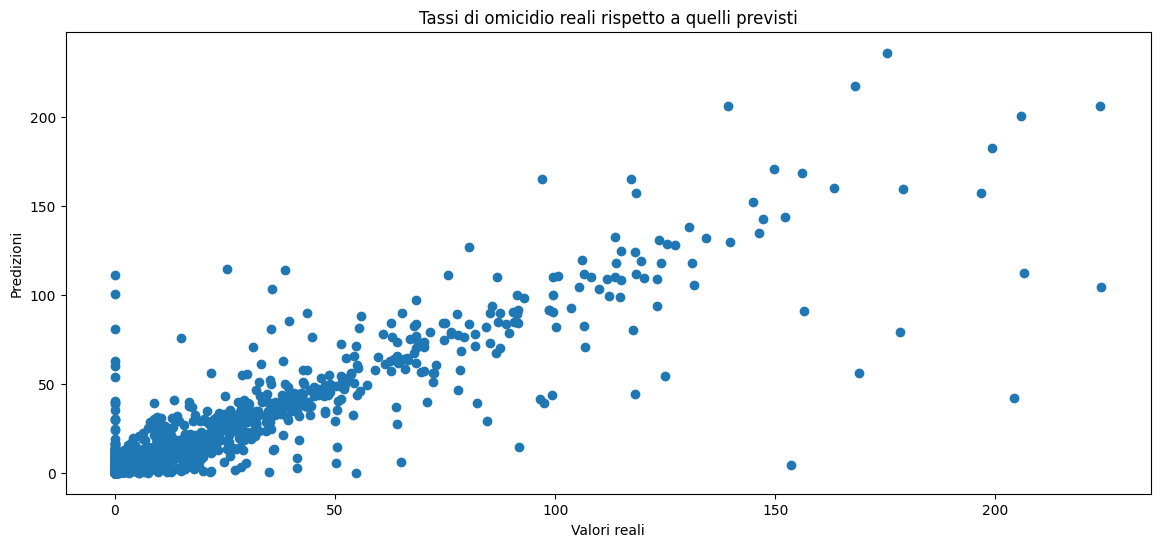

In [13]:
import matplotlib.pyplot as plt

pred = model.predict(X_test)

plt.figure(figsize=(14,6))
plt.scatter(y_test, pred)
plt.xlabel("Valori reali")
plt.ylabel("Predizioni")
plt.title("Tassi di omicidio reali rispetto a quelli previsti")
plt.show()

## Confronto tra valori reali e predetti

Il grafico mostra la relazione tra i **tassi di omicidio reali** presenti nel dataset (asse orizzontale) e le **predizioni generate dal modello** (asse verticale).

Ogni punto rappresenta un'osservazione del set di test. In un modello perfetto, tutti i punti dovrebbero trovarsi lungo la **linea diagonale ideale**, dove il valore predetto coincide esattamente con quello reale.

Nel grafico si osserva che:

- molti punti si distribuiscono lungo una **tendenza crescente**, indicando che il modello riesce a catturare la relazione generale nei dati;
- per valori bassi e moderati del tasso di omicidi le predizioni risultano relativamente vicine ai valori reali;
- per valori molto elevati si osserva una **maggiore dispersione**, segno che il modello ha più difficoltà a stimare correttamente gli estremi della distribuzione.

Questo comportamento è comune nei dataset con **forte variabilità tra paesi**, dove alcuni contesti presentano tassi di omicidio molto più elevati rispetto alla maggior parte delle osservazioni.

Nel complesso, il grafico conferma che il modello riesce a riprodurre il pattern generale dei dati, pur mostrando una minore precisione nei casi con valori estremi.

## Conclusioni

Questo notebook ha esplorato un dataset sui tassi di omicidio per paese, anno, sesso e gruppo di età, con l'obiettivo di costruire un semplice modello di machine learning in grado di stimare il tasso di omicidi (per 100.000 abitanti) a partire da queste variabili.

Dopo la fase di preparazione dei dati e codifica delle variabili categoriche, è stato addestrato un modello **Random Forest Regressor** per apprendere le relazioni tra le caratteristiche del dataset e il tasso di omicidi osservato.

Le prestazioni del modello sui dati di test sono risultate:

- **MAE (Mean Absolute Error):** 2.51  
- **RMSE (Root Mean Squared Error):** 8.54  
- **R²:** 0.83  

Il valore di **R² pari a circa 0.83** indica che il modello riesce a spiegare una parte consistente della variabilità dei tassi di omicidio nel dataset. Tuttavia, l'RMSE relativamente elevato suggerisce che in presenza di valori estremi (ad esempio paesi con tassi molto alti) il modello può produrre errori più grandi.

È importante sottolineare che questo modello rappresenta **una dimostrazione tecnica di analisi e modellazione dei dati**, e non deve essere interpretato come uno strumento affidabile di previsione reale. Le dinamiche della criminalità dipendono infatti da numerosi fattori sociali, economici, istituzionali e culturali che non sono inclusi in questo dataset.

### Possibili sviluppi futuri

Questo lavoro può essere esteso in diversi modi:

- integrazione di **variabili socio-economiche** (PIL, disuguaglianza, disoccupazione, urbanizzazione);
- utilizzo di **feature temporali** (lag, trend, medie mobili);
- sperimentazione con modelli più avanzati per dati tabellari come **XGBoost, LightGBM o CatBoost**;
- analisi comparativa delle dinamiche dei tassi di omicidio tra paesi e gruppi demografici.

Nel complesso, il progetto mostra come tecniche di **data science e machine learning** possano essere utilizzate per esplorare dataset complessi e individuare pattern nei dati.